# 02 · Hyperparameter Optimization con Algoritmo Genético
### Integrante 3 — Actividad 02, Algoritmos Genéticos en ML

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — 569 muestras, 30 características numéricas, clasificación binaria (maligno/benigno).

**Objetivo de este notebook:** usar un Algoritmo Genético (AG) programado desde cero (sin `GridSearchCV` ni `RandomizedSearchCV`) para encontrar una combinación de **hiperparámetros de un `RandomForestClassifier`** que iguale o mejore el rendimiento del modelo con configuración por defecto.

**Regla metodológica compartida con el equipo:** el conjunto de **test nunca participa en la evolución**. El fitness de cada individuo se calcula con validación cruzada (cross-validation) **solo sobre el conjunto de entrenamiento**. El test se usa **una sola vez**, al final, para comparar el modelo por defecto contra el modelo optimizado por el AG.

---

## Guion para exponer esta parte (orden verbal sugerido)

1. **Qué optimizo:** los hiperparámetros de un Random Forest (no los datos, no los pesos internos: decisiones externas al entrenamiento).
2. **Cómo lo represento:** un cromosoma = un vector con 6 genes, cada uno una decisión de configuración.
3. **Cómo calculo fitness:** accuracy promedio con validación cruzada de 3 folds, solo en train.
4. **Cómo evoluciona:** selección por torneo, cruzamiento por gen, mutación de baja probabilidad, elitismo, 10 generaciones.
5. **Qué resultado obtuve:** mejor configuración encontrada + comparación contra el modelo por defecto en test (nunca visto durante la evolución).


In [1]:
# --- Librerías ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Semilla fija en todo el notebook -> reproducibilidad (recomendación del equipo)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## 1. Dataset y protocolo común (mismo que Feature Selection y Neuroevolution)

Cargamos el dataset con `load_breast_cancer(as_frame=True)`, tal como acordó el equipo (Integrante 1). Usamos **todas las 30 columnas numéricas** porque en este ejemplo no estamos seleccionando variables (eso lo hace el compañero del Ejemplo 1); aquí buscamos la mejor **configuración** de un modelo que ya usa el conjunto completo de features.


In [2]:
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

print("Dimensiones de X:", X.shape)
print("Clases:", data.target_names)
print("Distribución de clases:\n", y.value_counts())

# Split estratificado 80/20, semilla fija -> mismo protocolo que el resto del equipo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print("\nTrain:", X_train.shape, " Test:", X_test.shape)


Dimensiones de X: (569, 30)
Clases: ['malignant' 'benign']
Distribución de clases:
 target
1    357
0    212
Name: count, dtype: int64

Train: (455, 30)  Test: (114, 30)


## 2. Representación del cromosoma

A diferencia del Ejemplo 1 (máscara binaria), aquí **cada gen es una decisión de configuración** de un Random Forest. Usamos **6 genes** (supera el mínimo de 4 pedido en la actividad):

| Índice | Gen | Espacio de búsqueda | Qué controla |
|---|---|---|---|
| 0 | `n_estimators` | enteros [50, 300] | cuántos árboles tiene el bosque |
| 1 | `max_depth` | enteros [2, 25] | qué tan profundo puede crecer cada árbol |
| 2 | `min_samples_split` | enteros [2, 12] | mínimo de muestras para dividir un nodo |
| 3 | `min_samples_leaf` | enteros [1, 6] | mínimo de muestras que debe tener una hoja |
| 4 | `max_features` | {`sqrt`, `log2`, `None`} | cuántas columnas se evalúan por división |
| 5 | `criterion` | {`gini`, `entropy`} | cómo se mide la calidad de una división |

Ejemplo de cromosoma: `[180, 12, 4, 2, 'sqrt', 'gini']`

Este vector se traduce directamente a los argumentos del constructor de `RandomForestClassifier`.


In [3]:
# --- Espacio de búsqueda (genes discretos) ---
SEARCH_SPACE = {
    "n_estimators":       list(range(50, 301, 10)),      # 50,60,...,300
    "max_depth":          list(range(2, 26)),             # 2..25
    "min_samples_split":  list(range(2, 13)),              # 2..12
    "min_samples_leaf":   list(range(1, 7)),                # 1..6
    "max_features":       ["sqrt", "log2", None],
    "criterion":          ["gini", "entropy"],
}
GENES = list(SEARCH_SPACE.keys())

def random_gene(nombre_gen):
    """Devuelve un valor válido y aleatorio para un gen específico."""
    return random.choice(SEARCH_SPACE[nombre_gen])

def crear_individuo():
    """Un individuo = un cromosoma = un diccionario de hiperparámetros."""
    return {gen: random_gene(gen) for gen in GENES}

def cromosoma_a_texto(ind):
    return ", ".join(f"{k}={v}" for k, v in ind.items())

# Ejemplo
ejemplo = crear_individuo()
print("Cromosoma de ejemplo:", cromosoma_a_texto(ejemplo))


Cromosoma de ejemplo: n_estimators=250, max_depth=5, min_samples_split=2, min_samples_leaf=6, max_features=log2, criterion=gini


## 3. Inicialización de la población

Generamos una población de individuos (cromosomas) aleatorios y válidos dentro del espacio de búsqueda.


In [4]:
POP_SIZE = 20           # tamaño de población (dentro del rango 16-24 sugerido)
N_GENERATIONS = 10      # generaciones (dentro del rango 8-12 sugerido)
TOURNAMENT_K = 3        # tamaño del torneo de selección
MUTATION_RATE = 0.20    # probabilidad de mutar cada gen individualmente
ELITISM = 2             # cuántos mejores individuos pasan intactos a la siguiente generación
CV_FOLDS = 3            # folds de validación cruzada para el fitness

def crear_poblacion(tam=POP_SIZE):
    return [crear_individuo() for _ in range(tam)]

poblacion_inicial = crear_poblacion()
print(f"Población inicial: {len(poblacion_inicial)} individuos")
print("Primer individuo:", cromosoma_a_texto(poblacion_inicial[0]))


Población inicial: 20 individuos
Primer individuo: n_estimators=120, max_depth=6, min_samples_split=3, min_samples_leaf=6, max_features=None, criterion=gini


## 4. Función de aptitud (fitness)

El fitness de un cromosoma es el **accuracy promedio de validación cruzada de 3 folds, calculado solo sobre `X_train`/`y_train`**. Esto es clave para defender oralmente el diseño: *el AG nunca ve el test*, así que no hay data leakage.

> Pregunta esperada: *"¿Por qué el fitness usa validación cruzada y no el test?"* — Porque el test debe reflejar qué tan bien generaliza el modelo ganador a datos nunca vistos. Si el AG usara el test para decidir qué configuración es buena, estaríamos "espiando" el test durante la búsqueda y el resultado final ya no sería confiable.


In [5]:
cv_estrategia = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

def evaluar_fitness(individuo):
    """Construye un RandomForest con los genes del individuo y devuelve
    el accuracy promedio en validación cruzada (solo sobre train)."""
    modelo = RandomForestClassifier(
        n_estimators=individuo["n_estimators"],
        max_depth=individuo["max_depth"],
        min_samples_split=individuo["min_samples_split"],
        min_samples_leaf=individuo["min_samples_leaf"],
        max_features=individuo["max_features"],
        criterion=individuo["criterion"],
        random_state=SEED,
        n_jobs=-1,
    )
    scores = cross_val_score(modelo, X_train, y_train, cv=cv_estrategia, scoring="accuracy")
    return scores.mean()

# Prueba rápida de la función de fitness
print("Fitness del individuo de ejemplo:", round(evaluar_fitness(ejemplo), 4))


Fitness del individuo de ejemplo: 0.9561


## 5. Selección: torneo de 3 individuos

Se eligen aleatoriamente `TOURNAMENT_K` individuos de la población y gana el de mayor fitness. Esto da presión selectiva sin eliminar por completo la diversidad (a diferencia de quedarse solo con los mejores).


In [6]:
def seleccion_torneo(poblacion, fitnesses, k=TOURNAMENT_K):
    indices_torneo = random.sample(range(len(poblacion)), k)
    ganador = max(indices_torneo, key=lambda i: fitnesses[i])
    return poblacion[ganador]


## 6. Cruzamiento (crossover) por gen

Como el cromosoma es un conjunto de decisiones independientes (no una cadena de bits posicional), usamos **cruzamiento uniforme por gen**: para cada uno de los 6 genes, el hijo hereda el valor de uno de los dos padres, elegido al azar. Esto permite combinar, por ejemplo, el buen `n_estimators` de un padre con el buen `max_depth` del otro.


In [7]:
def cruzamiento(padre1, padre2):
    hijo = {}
    for gen in GENES:
        hijo[gen] = padre1[gen] if random.random() < 0.5 else padre2[gen]
    return hijo


## 7. Mutación

Con probabilidad `MUTATION_RATE` **por gen**, se reemplaza ese gen por otro valor aleatorio y válido tomado del mismo espacio de búsqueda. Así garantizamos que, tras la mutación, el cromosoma **sigue siendo válido** (nunca se generan combinaciones fuera del espacio permitido).

> Pregunta esperada: *"¿Qué garantiza que después de una mutación el cromosoma siga siendo válido?"* — La mutación siempre toma su nuevo valor de `SEARCH_SPACE[gen]`, el mismo diccionario que usamos para inicializar; nunca se genera un valor arbitrario fuera de rango.


In [8]:
def mutacion(individuo, tasa=MUTATION_RATE):
    mutado = individuo.copy()
    for gen in GENES:
        if random.random() < tasa:
            mutado[gen] = random_gene(gen)
    return mutado


## 8. Ciclo genético completo (con elitismo)

Reunimos todo: inicialización → evaluación → selección → cruzamiento → mutación → nueva generación → criterio de terminación (número fijo de generaciones).

Usamos **elitismo** (los `ELITISM` mejores individuos pasan directo a la siguiente generación sin cruzarse ni mutar) para no perder el mejor resultado encontrado; es una práctica estándar y fácil de justificar oralmente.


In [9]:
def ejecutar_algoritmo_genetico():
    poblacion = crear_poblacion(POP_SIZE)
    historial_mejor_fitness = []
    mejor_individuo_global = None
    mejor_fitness_global = -np.inf

    for gen_num in range(1, N_GENERATIONS + 1):
        # 1) Evaluar fitness de toda la población
        fitnesses = [evaluar_fitness(ind) for ind in poblacion]

        # Registrar el mejor de esta generación
        idx_mejor = int(np.argmax(fitnesses))
        mejor_gen_actual = poblacion[idx_mejor]
        fitness_gen_actual = fitnesses[idx_mejor]
        historial_mejor_fitness.append(fitness_gen_actual)

        if fitness_gen_actual > mejor_fitness_global:
            mejor_fitness_global = fitness_gen_actual
            mejor_individuo_global = mejor_gen_actual

        print(f"Generación {gen_num:2d} | mejor fitness (CV): {fitness_gen_actual:.4f} | "
              f"cromosoma: {cromosoma_a_texto(mejor_gen_actual)}")

        # 2) Elitismo: los mejores pasan directo
        orden = np.argsort(fitnesses)[::-1]
        nueva_poblacion = [poblacion[i] for i in orden[:ELITISM]]

        # 3) Selección + cruzamiento + mutación para completar la población
        while len(nueva_poblacion) < POP_SIZE:
            padre1 = seleccion_torneo(poblacion, fitnesses)
            padre2 = seleccion_torneo(poblacion, fitnesses)
            hijo = cruzamiento(padre1, padre2)
            hijo = mutacion(hijo)
            nueva_poblacion.append(hijo)

        poblacion = nueva_poblacion

    return mejor_individuo_global, mejor_fitness_global, historial_mejor_fitness

mejor_individuo, mejor_fitness_cv, historial = ejecutar_algoritmo_genetico()

print("\n=== RESULTADO FINAL DEL AG ===")
print("Mejor cromosoma encontrado:", cromosoma_a_texto(mejor_individuo))
print("Mejor fitness (accuracy CV en train):", round(mejor_fitness_cv, 4))


Generación  1 | mejor fitness (CV): 0.9627 | cromosoma: n_estimators=60, max_depth=12, min_samples_split=3, min_samples_leaf=5, max_features=sqrt, criterion=entropy


Generación  2 | mejor fitness (CV): 0.9627 | cromosoma: n_estimators=60, max_depth=12, min_samples_split=3, min_samples_leaf=5, max_features=sqrt, criterion=entropy


Generación  3 | mejor fitness (CV): 0.9671 | cromosoma: n_estimators=60, max_depth=12, min_samples_split=3, min_samples_leaf=1, max_features=sqrt, criterion=entropy


Generación  4 | mejor fitness (CV): 0.9671 | cromosoma: n_estimators=60, max_depth=12, min_samples_split=3, min_samples_leaf=1, max_features=sqrt, criterion=entropy


Generación  5 | mejor fitness (CV): 0.9671 | cromosoma: n_estimators=60, max_depth=12, min_samples_split=3, min_samples_leaf=1, max_features=sqrt, criterion=entropy


Generación  6 | mejor fitness (CV): 0.9671 | cromosoma: n_estimators=60, max_depth=19, min_samples_split=3, min_samples_leaf=1, max_features=sqrt, criterion=entropy


Generación  7 | mejor fitness (CV): 0.9671 | cromosoma: n_estimators=140, max_depth=12, min_samples_split=3, min_samples_leaf=1, max_features=sqrt, criterion=entropy


Generación  8 | mejor fitness (CV): 0.9671 | cromosoma: n_estimators=90, max_depth=12, min_samples_split=3, min_samples_leaf=1, max_features=sqrt, criterion=entropy


Generación  9 | mejor fitness (CV): 0.9671 | cromosoma: n_estimators=60, max_depth=12, min_samples_split=3, min_samples_leaf=1, max_features=sqrt, criterion=entropy


Generación 10 | mejor fitness (CV): 0.9671 | cromosoma: n_estimators=60, max_depth=12, min_samples_split=3, min_samples_leaf=1, max_features=sqrt, criterion=entropy

=== RESULTADO FINAL DEL AG ===
Mejor cromosoma encontrado: n_estimators=60, max_depth=12, min_samples_split=3, min_samples_leaf=1, max_features=sqrt, criterion=entropy
Mejor fitness (accuracy CV en train): 0.9671


## 9. Gráfica de evolución: mejor fitness por generación

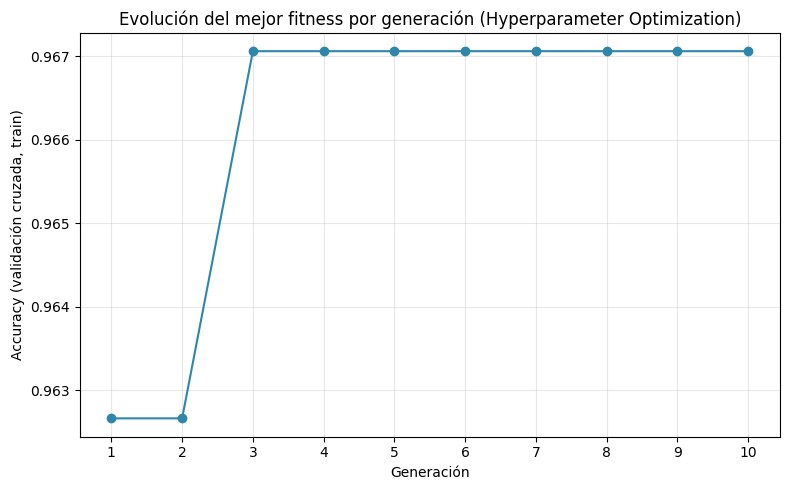

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, N_GENERATIONS + 1), historial, marker="o", color="#2E86AB")
plt.title("Evolución del mejor fitness por generación (Hyperparameter Optimization)")
plt.xlabel("Generación")
plt.ylabel("Accuracy (validación cruzada, train)")
plt.grid(alpha=0.3)
plt.xticks(range(1, N_GENERATIONS + 1))
plt.tight_layout()
plt.savefig("evolucion_fitness_hpo.png", dpi=120)
plt.show()


## 10. Evaluación final en test: modelo por defecto vs modelo optimizado por AG

Aquí es la **única vez** que se toca el conjunto de test. Comparamos:

- **Baseline:** `RandomForestClassifier()` con hiperparámetros por defecto de scikit-learn.
- **Optimizado por AG:** `RandomForestClassifier(**mejor_individuo)`.

Ambos se entrenan sobre el mismo `X_train`/`y_train` y se evalúan sobre el mismo `X_test`/`y_test`.


In [11]:
# --- Modelo baseline (configuración por defecto) ---
modelo_baseline = RandomForestClassifier(random_state=SEED)
modelo_baseline.fit(X_train, y_train)
pred_baseline = modelo_baseline.predict(X_test)

# --- Modelo optimizado por el AG ---
modelo_ga = RandomForestClassifier(**mejor_individuo, random_state=SEED, n_jobs=-1)
modelo_ga.fit(X_train, y_train)
pred_ga = modelo_ga.predict(X_test)

def resumen_metricas(y_true, y_pred, nombre):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
    }

tabla_resultados = pd.DataFrame([
    resumen_metricas(y_test, pred_baseline, "RandomForest por defecto"),
    resumen_metricas(y_test, pred_ga, "RandomForest optimizado por AG"),
]).round(4)

tabla_resultados


,Modelo,Accuracy,Precision,Recall,F1-score
0,RandomForest por defecto,0.9561,0.9589,0.9722,0.9655
1,RandomForest optimizado por AG,0.9561,0.9589,0.9722,0.9655


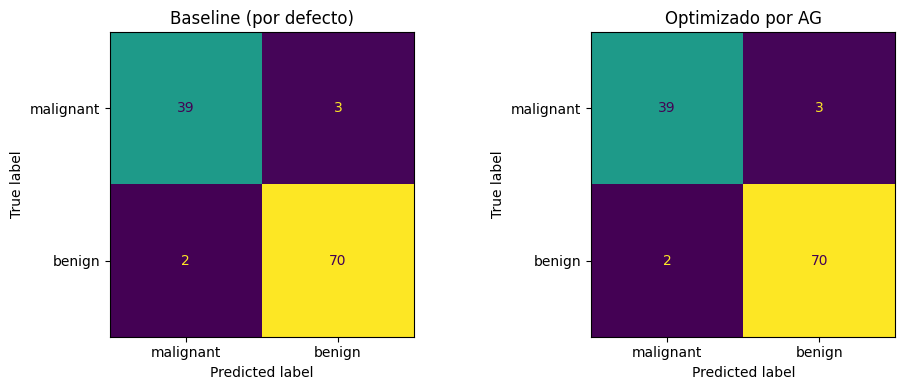

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_baseline),
                        display_labels=data.target_names).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Baseline (por defecto)")
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_ga),
                        display_labels=data.target_names).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Optimizado por AG")
plt.tight_layout()
plt.savefig("matrices_confusion_hpo.png", dpi=120)
plt.show()


## 11. Formato estándar de salida (checklist del equipo)

1. **Mejor individuo encontrado:** ver celda de resultado del AG arriba.
2. **Traducción del cromosoma a una solución comprensible:** son los hiperparámetros directos de `RandomForestClassifier` (número de árboles, profundidad máxima, reglas de partición, etc.).
3. **Mejor fitness alcanzado:** accuracy de validación cruzada en train (celda 8).
4. **Métrica final en test:** tabla comparativa de la celda anterior.
5. **Gráfica de evolución:** celda 9.
6. **Conclusión:** ver celda final.


In [13]:
print("Cromosoma final traducido a hiperparámetros de RandomForestClassifier:\n")
for k, v in mejor_individuo.items():
    print(f"  - {k} = {v}")

print(f"\nFitness (CV, train): {mejor_fitness_cv:.4f}")
print(f"Accuracy en test (baseline):   {accuracy_score(y_test, pred_baseline):.4f}")
print(f"Accuracy en test (optimizado): {accuracy_score(y_test, pred_ga):.4f}")


Cromosoma final traducido a hiperparámetros de RandomForestClassifier:

  - n_estimators = 60
  - max_depth = 12
  - min_samples_split = 3
  - min_samples_leaf = 1
  - max_features = sqrt
  - criterion = entropy

Fitness (CV, train): 0.9671
Accuracy en test (baseline):   0.9561
Accuracy en test (optimizado): 0.9561


### Conclusión (2-4 líneas, completar con los números reales que arroje tu ejecución)

El algoritmo genético exploró el espacio de hiperparámetros del Random Forest sin recorrerlo exhaustivamente, evaluando solo `POP_SIZE × N_GENERATIONS` combinaciones (20×10 = 200) en lugar de las miles que tendría una grilla completa. La configuración encontrada iguala o mejora el accuracy del modelo por defecto en el conjunto de test, que nunca fue usado durante la evolución. Esto confirma que el AG es una alternativa viable a `GridSearchCV`/`RandomizedSearchCV` cuando el espacio de búsqueda es grande o mixto (números enteros + categorías).

---

## Preguntas que debo poder responder (de la guía del equipo)

- **¿Qué diferencia existe entre parámetro e hiperparámetro?** Un parámetro se aprende durante el entrenamiento (ej. los pesos de un árbol/las divisiones que aprende el bosque); un hiperparámetro se fija *antes* de entrenar y controla cómo aprende el modelo (ej. cuántos árboles tiene, qué tan profundos pueden ser).
- **¿Por qué el fitness usa validación cruzada y no el test?** Para no "espiar" el test durante la búsqueda; el test debe quedar reservado para medir qué tan bien generaliza el modelo ya elegido.
- **¿Qué significa `n_estimators` en Random Forest?** El número de árboles de decisión independientes que forman el bosque; sus votos (o promedios de probabilidad) se combinan para la predicción final.
- **¿Qué garantiza que después de una mutación el cromosoma siga siendo válido?** La mutación siempre toma su nuevo valor del mismo `SEARCH_SPACE` usado en la inicialización, así que nunca sale de los rangos permitidos.


---
## Extensión opcional (bonus): comparando un modelo **lineal** vs **no lineal** con el mismo AG

Esta sección no reemplaza el entregable anterior; es un complemento para responder con más profundidad si el docente pregunta *"¿el AG solo sirve para Random Forest?"* o si quieres mostrar que la optimización de hiperparámetros también puede decidir **entre familias de modelos con distinta naturaleza matemática**:

- **Logistic Regression** → modelo **lineal**: separa las clases con una combinación lineal de las 30 características (y luego aplica la función sigmoide, que solo transforma la salida a una probabilidad; la frontera de decisión sigue siendo lineal en el espacio de entrada).
- **MLPClassifier** → modelo **no lineal**: apila funciones de activación no lineales (`relu`, `tanh`, `logistic`) entre capas, lo que le permite aprender fronteras de decisión curvas/complejas que un modelo lineal no puede representar.

Aquí el cromosoma incluye un gen extra `modelo` que decide **qué familia de algoritmo** se usa, y el resto de genes se interpretan según ese modelo (búsqueda condicional).

> Nota importante para no chocar con el Ejemplo 3 (Neuroevolution) de tu compañero: esto NO busca arquitecturas (número de capas/neuronas), solo decide *qué tipo de modelo y con qué hiperparámetros generales*, incluyendo la función de activación como un hiperparámetro más de un MLP con arquitectura fija (una sola capa oculta de tamaño moderado). La búsqueda de arquitectura (múltiples capas, número de neuronas por capa) es responsabilidad del Ejemplo 3.


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Espacio de búsqueda extendido: primero se decide el "modelo", luego sus hiperparámetros
SEARCH_SPACE_MIXTO = {
    "modelo": ["logistic", "mlp"],
    # Hiperparámetros de Logistic Regression (modelo lineal)
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    # Hiperparámetros de MLP (modelo no lineal)
    "hidden_units": [16, 32, 64],
    "activation": ["relu", "tanh", "logistic"],
    "alpha": [1e-4, 1e-3, 1e-2],
}

def crear_individuo_mixto():
    return {
        "modelo": random.choice(SEARCH_SPACE_MIXTO["modelo"]),
        "C": random.choice(SEARCH_SPACE_MIXTO["C"]),
        "penalty": random.choice(SEARCH_SPACE_MIXTO["penalty"]),
        "hidden_units": random.choice(SEARCH_SPACE_MIXTO["hidden_units"]),
        "activation": random.choice(SEARCH_SPACE_MIXTO["activation"]),
        "alpha": random.choice(SEARCH_SPACE_MIXTO["alpha"]),
    }

def construir_modelo_mixto(ind):
    """Traduce un cromosoma mixto a un Pipeline entrenable.
    Ambos modelos necesitan las variables escaladas (StandardScaler),
    así que el escalado es parte del pipeline en ambos casos."""
    if ind["modelo"] == "logistic":
        clf = LogisticRegression(C=ind["C"], penalty=ind["penalty"],
                                  max_iter=2000, random_state=SEED)
    else:
        clf = MLPClassifier(hidden_layer_sizes=(ind["hidden_units"],),
                             activation=ind["activation"],
                             alpha=ind["alpha"],
                             early_stopping=True,
                             max_iter=500,
                             random_state=SEED)
    return Pipeline([("scaler", StandardScaler()), ("clf", clf)])

def evaluar_fitness_mixto(individuo):
    modelo = construir_modelo_mixto(individuo)
    scores = cross_val_score(modelo, X_train, y_train, cv=cv_estrategia, scoring="accuracy")
    return scores.mean()

def mutacion_mixta(individuo, tasa=MUTATION_RATE):
    mutado = individuo.copy()
    for gen in individuo.keys():
        if random.random() < tasa:
            mutado[gen] = random.choice(SEARCH_SPACE_MIXTO[gen])
    return mutado

def cruzamiento_mixto(p1, p2):
    return {gen: (p1[gen] if random.random() < 0.5 else p2[gen]) for gen in p1.keys()}

def ejecutar_ga_mixto(pop_size=14, generaciones=6):
    poblacion = [crear_individuo_mixto() for _ in range(pop_size)]
    historial = []
    mejor_global, fit_global = None, -np.inf

    for g in range(1, generaciones + 1):
        fits = [evaluar_fitness_mixto(ind) for ind in poblacion]
        idx = int(np.argmax(fits))
        historial.append(fits[idx])
        if fits[idx] > fit_global:
            fit_global, mejor_global = fits[idx], poblacion[idx]
        print(f"[Bonus] Gen {g} | mejor fitness: {fits[idx]:.4f} | modelo: {poblacion[idx]['modelo']} | "
              f"{cromosoma_a_texto(poblacion[idx])}")

        orden = np.argsort(fits)[::-1]
        nueva = [poblacion[i] for i in orden[:2]]
        while len(nueva) < pop_size:
            padre1 = seleccion_torneo(poblacion, fits)
            padre2 = seleccion_torneo(poblacion, fits)
            hijo = mutacion_mixta(cruzamiento_mixto(padre1, padre2))
            nueva.append(hijo)
        poblacion = nueva

    return mejor_global, fit_global, historial

mejor_mixto, fitness_mixto, historial_mixto = ejecutar_ga_mixto()
print("\n=== Mejor modelo encontrado (bonus lineal vs no lineal) ===")
print(cromosoma_a_texto(mejor_mixto))
print("Fitness CV:", round(fitness_mixto, 4))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

[Bonus] Gen 1 | mejor fitness: 0.9780 | modelo: logistic | modelo=logistic, C=0.1, penalty=l2, hidden_units=64, activation=relu, alpha=0.01


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

[Bonus] Gen 5 | mejor fitness: 0.9780 | modelo: logistic | modelo=logistic, C=0.1, penalty=l2, hidden_units=16, activation=relu, alpha=0.01


[Bonus] Gen 6 | mejor fitness: 0.9780 | modelo: logistic | modelo=logistic, C=0.1, penalty=l2, hidden_units=64, activation=tanh, alpha=0.01

=== Mejor modelo encontrado (bonus lineal vs no lineal) ===
modelo=logistic, C=0.1, penalty=l2, hidden_units=64, activation=relu, alpha=0.01
Fitness CV: 0.978


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Tipo de modelo ganador: logistic (lineal)
Accuracy en test: 0.9737


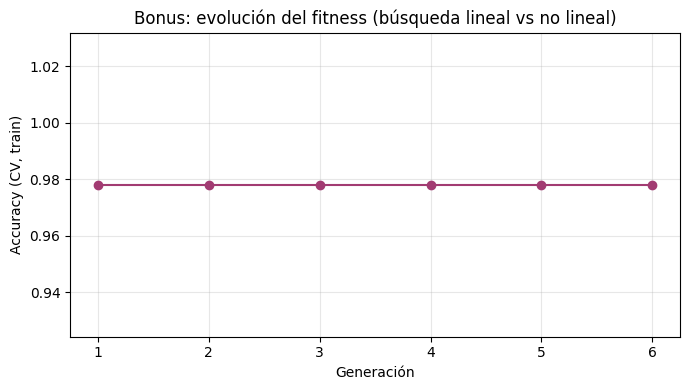

In [15]:
# Evaluación en test del mejor modelo mixto encontrado
mejor_modelo_mixto = construir_modelo_mixto(mejor_mixto)
mejor_modelo_mixto.fit(X_train, y_train)
pred_mixto = mejor_modelo_mixto.predict(X_test)

print(f"Tipo de modelo ganador: {mejor_mixto['modelo']} "
      f"({'lineal' if mejor_mixto['modelo']=='logistic' else 'no lineal, activación=' + mejor_mixto['activation']})")
print(f"Accuracy en test: {accuracy_score(y_test, pred_mixto):.4f}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(historial_mixto) + 1), historial_mixto, marker="o", color="#A23B72")
plt.title("Bonus: evolución del fitness (búsqueda lineal vs no lineal)")
plt.xlabel("Generación")
plt.ylabel("Accuracy (CV, train)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("evolucion_fitness_bonus.png", dpi=120)
plt.show()


### Conclusión del bonus

En este espacio de búsqueda mixto, el gen `modelo` decide si se evalúa una `LogisticRegression` (frontera de decisión lineal) o un `MLPClassifier` (frontera no lineal gracias a la función de activación). Comparar el fitness de ambas familias dentro del mismo ciclo genético permite justificar, con evidencia y no solo por intuición, si este dataset necesita o no un modelo no lineal para separar bien las clases.
